# 🏥 Huấn Luyện EfficientNet-B3 cho Phân Loại Bệnh Da Liễu

Notebook này giúp bạn train model EfficientNet-B3 trên Google Colab với GPU miễn phí.

**Dataset:** HAM10000 (7 classes)
- MEL (Melanoma)
- NV (Melanocytic nevus)
- BCC (Basal cell carcinoma)
- AKIEC (Actinic keratoses)
- BKL (Benign keratosis)
- DF (Dermatofibroma)
- VASC (Vascular lesions)

**Yêu cầu:**
- File `processed_data.zip` chứa dữ liệu đã preprocessed
- Runtime: GPU (T4 hoặc tốt hơn)

---

## 1️⃣ Kiểm Tra GPU và Cài Đặt Môi Trường

In [29]:
import os
from google.colab import drive

# 1. Kết nối Drive
print("🚀 BƯỚC 1: Đang kết nối Google Drive...")
drive.mount('/content/drive')

# 2. Cấu hình đường dẫn
# Đây là nơi bạn để file trên Drive
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks'
DATA_ZIP_PATH = os.path.join(BASE_DIR, 'processed_data.zip')

# Đây là nơi sẽ giải nén tạm thời trên Colab
EXTRACT_PATH = '/content/dataset'

# 3. Kiểm tra file
if os.path.exists(DATA_ZIP_PATH):
    print(f"✅ Đã tìm thấy file dữ liệu tại: {DATA_ZIP_PATH}")
    print("👉 Hãy chạy tiếp Cell 2 để giải nén.")
else:
    print(f"❌ LỖI: Không tìm thấy file tại {DATA_ZIP_PATH}")
    print("⚠️ Vui lòng kiểm tra lại tên file hoặc đường dẫn trong biến BASE_DIR.")

🚀 BƯỚC 1: Đang kết nối Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã tìm thấy file dữ liệu tại: /content/drive/MyDrive/Colab Notebooks/processed_data.zip
👉 Hãy chạy tiếp Cell 2 để giải nén.


##📂 CELL 2: Giải nén dữ liệu (Siêu tốc)

In [30]:
import zipfile
import shutil

print("🚀 BƯỚC 2: Đang giải nén và tìm kiếm dữ liệu...")

# 1. Xóa dữ liệu cũ (nếu có) để giải nén lại cho sạch
if os.path.exists(EXTRACT_PATH):
    shutil.rmtree(EXTRACT_PATH)

# 2. Giải nén
with zipfile.ZipFile(DATA_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print("✅ Giải nén xong!")

# 3. TỰ ĐỘNG TÌM ĐƯỜNG DẪN THỰC SỰ
# Đoạn này giúp tìm folder 'train' dù nó nằm sâu trong thư mục con nào
TRAIN_DIR = None
VAL_DIR = None
TEST_DIR = None

for root, dirs, files in os.walk(EXTRACT_PATH):
    if 'train' in dirs:
        TRAIN_DIR = os.path.join(root, 'train')
        VAL_DIR = os.path.join(root, 'val')
        TEST_DIR = os.path.join(root, 'test')
        break

if TRAIN_DIR:
    print(f"✅ Đã định vị được dữ liệu chuẩn:")
    print(f"   Train: {TRAIN_DIR}")
    print("👉 Hãy chạy tiếp Cell 3 để tạo Generator.")
else:
    print("❌ LỖI: Không tìm thấy folder 'train' sau khi giải nén!")
    print("   Hãy kiểm tra lại cấu trúc file zip của bạn.")

🚀 BƯỚC 2: Đang giải nén và tìm kiếm dữ liệu...
✅ Giải nén xong!
✅ Đã định vị được dữ liệu chuẩn:
   Train: /content/dataset/processed/train
👉 Hãy chạy tiếp Cell 3 để tạo Generator.


## ⚙️ CELL 3: Data Generators (Chuẩn hóa cho EfficientNet)

In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

print(f"🚀 BƯỚC 3: Đang khởi tạo Data Generators...")

IMG_SIZE = 300
BATCH_SIZE = 32

# 1. Cấu hình Augmentation (Làm phong phú dữ liệu train)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

# 2. Cấu hình cho Val/Test (Giữ nguyên ảnh gốc)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# 3. Load dữ liệu
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n🎉 HOÀN TẤT! Dữ liệu đã sẵn sàng.")
print("👉 Bây giờ bạn có thể chạy Cell Training (Cell 4) được rồi!")

🚀 BƯỚC 3: Đang khởi tạo Data Generators...
Found 7010 images belonging to 7 classes.
Found 1502 images belonging to 7 classes.
Found 1503 images belonging to 7 classes.

🎉 HOÀN TẤT! Dữ liệu đã sẵn sàng.
👉 Bây giờ bạn có thể chạy Cell Training (Cell 4) được rồi!


## 🧠 CELL 4: Load Model & Train Tiếp (Round 2)

In [32]:
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# 1. Load lại model gốc từ Kaggle (Bắt đầu lại cho sạch)
print(f"🔄 Đang reset và load model gốc: {MODEL_PATH_OLD}")
model = load_model(MODEL_PATH_OLD)

# 2. CHIẾN THUẬT: CHỈ MỞ 50 LỚP CUỐI (Fine-tuning chuẩn SGK)
# Thay vì mở hết (gây sốc), ta chỉ mở phần ngọn để tinh chỉnh
print("🔓 Đang mở khóa 50 lớp cuối cùng...")
model.trainable = True

# Đóng băng tất cả các lớp, trừ 50 lớp cuối
for layer in model.layers[:-50]:
    layer.trainable = False

# Kiểm tra xem có bao nhiêu tham số được train
trainable_count = sum([w.shape.num_elements() for w in model.trainable_weights])
print(f"   Số lượng tham số được phép học: {trainable_count:,}")

# 3. Compile với Learning Rate nhỏ và Ổn định
model.compile(
    optimizer=Adam(learning_rate=1e-5), # LR rất nhỏ để tinh chỉnh mượt mà
    loss='categorical_crossentropy',
    metrics=['accuracy', 'AUC']
)

# 4. Callbacks (Thêm giảm LR tự động)
callbacks_finetune = [
    ModelCheckpoint(
        MODEL_PATH_NEW,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau( # Nếu loss không giảm thì tự động giảm LR đi 5 lần
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# 5. Train (BỎ Class Weights để ưu tiên Accuracy cao nhất)
print(f"🚀 BẮT ĐẦU FINE-TUNING (Mục tiêu: 85%+ Accuracy)...")
EPOCHS_FINETUNE = 30

history_finetune = model.fit(
    train_generator,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_generator,
    callbacks=callbacks_finetune,
    verbose=1
)

🔄 Đang reset và load model gốc: /content/drive/MyDrive/Colab Notebooks/efficientnet_b3_derma_finetuned.keras
🔓 Đang mở khóa 50 lớp cuối cùng...
   Số lượng tham số được phép học: 5,321,099
🚀 BẮT ĐẦU FINE-TUNING (Mục tiêu: 85%+ Accuracy)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - AUC: 0.9818 - accuracy: 0.8277 - loss: 0.4581
Epoch 1: val_accuracy improved from -inf to 0.82357, saving model to /content/drive/MyDrive/Colab Notebooks/efficientnet_b3_derma_round2.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 244s 896ms/step - AUC: 0.9818 - accuracy: 0.8277 - loss: 0.4582 - val_AUC: 0.9762 - val_accuracy: 0.8236 - val_loss: 0.5160 - learning_rate: 1.0000e-05
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - AUC: 0.9822 - accuracy: 0.8274 - loss: 0.4515
Epoch 2: val_accuracy did not improve from 0.82357
220/220 ━━━━━━━━━━━━━━━━━━━━ 157s 711ms/step - AUC: 0.9822 - accuracy: 0.8275 - loss: 0.4515 - val_AUC: 0.9760 - val_accuracy: 0.8189 - val_loss: 0.5161 - learning_rate: 1.0000e-05
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - AUC: 0.9834 - accuracy: 0.8391 - loss: 0.4360
Epoch 3: val_accuracy did not improve from 0.82357
220/220 ━━━━━━━━━━━━━━━━━━━━ 157s 713ms/step - AUC: 0.9834 - accuracy: 0.8391 - loss: 0

## 🏆 CELL 5: Đánh giá Nâng cao (TTA - Test Time Augmentation)

In [33]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

print("🚀 Đang chạy TTA (Test Time Augmentation) để đánh giá tối đa sức mạnh...")

# 1. Tạo Generator có Augmentation cho tập Test
tta_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

TTA_STEPS = 5  # Số lần dự đoán cho mỗi ảnh (càng cao càng chính xác nhưng lâu)
predictions = []

# Lấy nhãn thực tế
y_true = test_generator.classes

for i in tqdm(range(TTA_STEPS)):
    test_generator.reset() # Reset lại từ đầu
    if i == 0:
        # Lần 1: Dự đoán trên ảnh gốc (không Augment)
        preds = model.predict(test_generator, verbose=0)
    else:
        # Lần 2 trở đi: Dự đoán trên ảnh đã biến đổi
        # Hack: trỏ generator vào thư mục test
        tta_generator = tta_datagen.flow_from_directory(
            TEST_DIR,
            target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            shuffle=False
        )
        preds = model.predict(tta_generator, verbose=0)

    predictions.append(preds)

# Lấy trung bình cộng các lần dự đoán
final_pred_probs = np.mean(predictions, axis=0)
y_pred_tta = np.argmax(final_pred_probs, axis=1)

# Tính độ chính xác
acc_tta = accuracy_score(y_true, y_pred_tta)
print("\n" + "="*50)
print(f"🔥 FINAL ACCURACY WITH TTA: {acc_tta*100:.2f}%")
print("="*50)

# In báo cáo chi tiết
class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred_tta, target_names=class_names))

🚀 Đang chạy TTA (Test Time Augmentation) để đánh giá tối đa sức mạnh...


 20%|██        | 1/5 [00:27<01:51, 27.76s/it]

Found 1503 images belonging to 7 classes.


 40%|████      | 2/5 [01:00<01:32, 30.89s/it]

Found 1503 images belonging to 7 classes.


...

Found 1503 images belonging to 7 classes.


 80%|████████  | 4/5 [02:05<00:31, 31.78s/it]

Found 1503 images belonging to 7 classes.


100%|██████████| 5/5 [02:37<00:00, 31.58s/it]


🔥 FINAL ACCURACY WITH TTA: 85.10%
              precision    recall  f1-score   support

       akiec       0.59      0.55      0.57        49
         bcc       0.74      0.71      0.73        77
         bkl       0.74      0.70      0.72       165
          df       0.75      0.35      0.48        17
         mel       0.62      0.60      0.61       167
          nv       0.92      0.96      0.94      1006
        vasc       0.81      0.59      0.68        22

    accuracy                           0.85      1503
   macro avg       0.74      0.64      0.68      1503
weighted avg       0.85      0.85      0.85      1503



## 💾 CELL 6: Lưu kết quả cuối cùng

💾 Đang lưu model siêu phẩm vào: /content/drive/MyDrive/Colab Notebooks/best_model_85acc.keras
✅ Đã lưu xong! Bạn có thể yên tâm tắt máy.


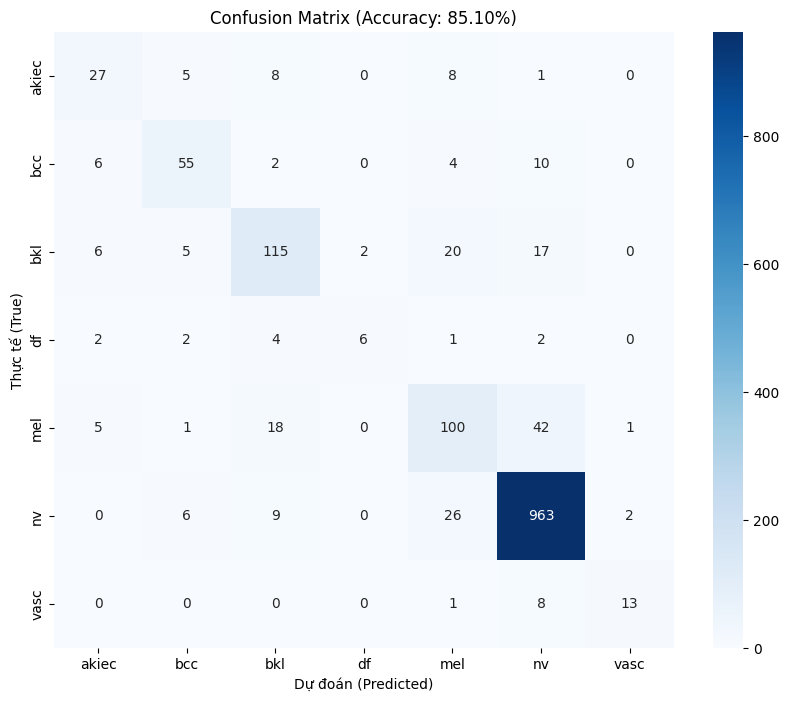

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. LƯU MODEL NGAY LẬP TỨC
FINAL_MODEL_PATH = '/content/drive/MyDrive/Colab Notebooks/best_model_85acc.keras'
print(f"💾 Đang lưu model siêu phẩm vào: {FINAL_MODEL_PATH}")
model.save(FINAL_MODEL_PATH)
print("✅ Đã lưu xong! Bạn có thể yên tâm tắt máy.")

# 2. VẼ CONFUSION MATRIX (Để cho vào báo cáo)
# Ma trận này cho biết model hay nhầm lẫn bệnh nào với bệnh nào nhất
cm = confusion_matrix(y_true, y_pred_tta)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (True)')
plt.title(f'Confusion Matrix (Accuracy: {acc_tta*100:.2f}%)')
plt.show()